In [4]:
import numpy as np
import matplotlib.pyplot as plt
import os, sys
sys.path.append('..')
sys.path.append('../gen_data/')
from utils import julio
import importlib
# importlib.reload(julio)
import pandas as pd
import src.observables as obs
importlib.reload(obs)
import utils.io as io
from read_corrs import read_corrs, select_dV
import matplotlib as mpl
# mpl.style.use('aps.mplstyle')
# import set_size_helper as ssh
# importlib.reload(ssh)

from scipy.fftpack import fft
import matplotlib as mpl
# mpl.style.use('aps.mplstyle')

In [2]:
all_files = []
for N in (64, 128, 256, ):
    for dV in np.arange(3.2, 4.0, 0.05):
        filename = julio.corr_filename_builder(N, 1.0, 0.1, 0.8, dV=dV)
        if os.path.exists(filename):
            all_files.append(filename)
df = julio.load_correlations_files(all_files)
df_i = pd.DataFrame()

idmrg_file_list_dict = {100 : '../../data/iDMRG/rev/scanChi100/corrs/results.h5',
                        200 : '../../data/iDMRG/rev/scanChi200/corrs/results.h5', 
                        400 : '../../data/iDMRG/rev/scanChi400/corrs/results.h5', 
                        800 : '../../data/iDMRG/scanChi800/corrs/results.h5',
                        1000: '../../data/iDMRG/scanChi1000/corrs/results.h5',
}
for chi, idmrg_file in idmrg_file_list_dict.items():
    df_i_chi = read_corrs(idmrg_file)
    df_i_chi['chi'] = chi
    df_i = pd.concat([df_i, df_i_chi])
df.keys(), df_i.keys()

(Index(['szmat', 'chargemat', 'spmmat', 'elecupmat', 'elecdnmat', 'sz_expect',
        'ntot_expect', 'xspin2', 'spin2vec', 'params', 'N', 'dV', 'Vpm',
        'szconn', 'chargeconn', 'spmconn', 'electron_conn', 'filename'],
       dtype='str'),
 Index(['basename', 'src_file', 'dV', 'mean_Sz', 'mean_fill', 'xi',
        'model_params', 'diagnostics', 'charge_corr', 'spinz_corr', 'spsm_corr',
        'electron_corr', 'spin2_corr', 'chi'],
       dtype='str'))

correlation length =  213.08966442133786


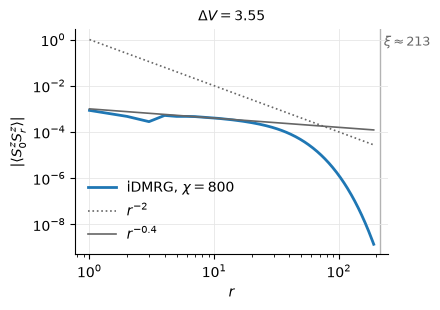

In [52]:
seldf = select_dV(df_i[df_i['chi']==800], 3.55, atol=1e-7)
spinzcorr = np.abs(seldf['spinz_corr'].values[0])
xi = seldf['xi'].values[0]
print('correlation length = ', xi)

r = np.arange(1, len(spinzcorr))  # skip r=0: undefined on log axes
fig, ax = plt.subplots(figsize=(4.5, 3.2))
ax.loglog(r, spinzcorr[1:], color='C0', lw=2, label=r'iDMRG, $\chi=800$')
ax.loglog(r, 1./r**2, color='0.4', lw=1.2, ls=':', label=r'$r^{-2}$')
ax.loglog(r, 0.001/r**0.4, color='0.4', lw=1.2, ls='-', label=r'$r^{-0.4}$')
ax.axvline(xi, color='0.7', lw=1, zorder=0)
ax.text(xi, 0.97, rf' $\xi \approx {xi:.0f}$', transform=ax.get_xaxis_transform(),
        va='top', fontsize=9, color='0.4')
ax.set_xlabel(r'$r$')
ax.set_ylabel(r'$|\langle S^z_0 S^z_r \rangle|$')
ax.set_title(rf'$\Delta V = 3.55$', fontsize=10)
ax.grid(which='major', color='0.9', lw=0.6)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(frameon=False)
fig.tight_layout()

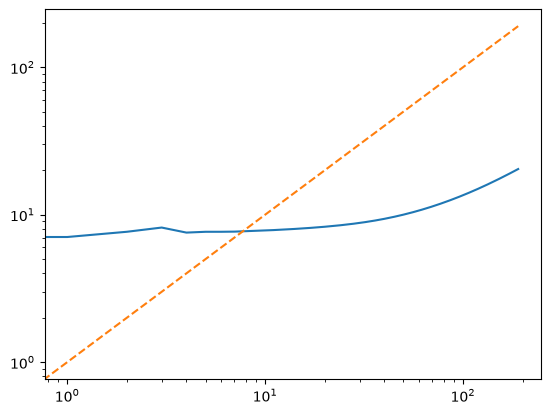

In [46]:
plt.plot(xvals, -np.log(spinzcorr))
plt.xscale('log')
plt.yscale('log')
plt.plot(xvals, ls='--')